<p style="text-align: center">
<img src="../../../assets/images/dtlogo.png" alt="Duckietown" width="50%">
</p>

# 💻 🚙 05 - PID: Heading control

The controller is where the decision making part of a robot's mind. 

Controllers output _commands_, which are signals that will be executed by our robot's actuators, with the objective of achieving a certain goal. The inputs to the controller are typically signals that helps define this goal.

For example, in the case of the Duckiebot, the (output) control signals are the linear velocity $v$ and angular velocity $\omega$ of the robot. In other words, the controller will decide, at every time instant, at what speed should the Duckiebot go and how much should it steer left or right to, for example, stay in the lane. 

The **P**roportional-**I**ntegral-**D**erivative (PID) controller is an example of a feedback controller where the goal is defined in terms of one or more tracking error signals ($e_t$), which are the input to the controller. The controller will try to bring the error ideally to zero, hence the system output ($y_t$) to match the reference signal ($r_t$). 

$$ e_t = r_t - y_t \rightarrow 0 \Rightarrow y_t \rightarrow r_t$$

<figure>
  <div style="text-align:center;">
  <img src="../../../assets/images/pid-control/pid-control-diagram.jpg" alt="pid-loop-2" style="width: 300px;"/>
  <p>A PID control loop.</p>
  </div>
</figure>

Consider a Duckiebot driving in the middle of a road with a constant linear velocity ($v_0$). In the lane following task our goal is to make sure the robot stays in the middle of the lane by adjusting its angular velocity. Intuitively, whenever the robot deviates from the middle of the lane, we will adjust the angular velocity so the robot turns toward the middle of the lane. The question is: by how much?

The name proportional-integral-derivative comes from the fact that the controller adjusts the control signals proportionally to the error at every time instant, while also considers the integral (i.e., the sum, or accumulation) of the error over time, and the derivative of the error at each time step (i.e., the rate of change of the error over time). 

The control command is calculated by considering the combination of these three components:

$$ u_t = k_p e(t) + k_i \int_0^t e(\tau) d \tau + k_d \frac{d e_t}{dt},$$

where $k_p$, $k_i$, and $k_d$ are the proportional, integral, and derivative coefficients of the controller, respectively, and weigh the three terms.

The PID control problem is to determine values for these parameters (e.g., via trial and error) until the closed loop system performs reasonably well. Typically (but it depends strongly on the complexity of the system):

- Increasing $k_p$ will decrease the the time it takes for the system to approach the reference point (i.e., rise time), but at the risk of overshooting the reference. A high $k_p$ leads to an aggressive control. 
- Increasing $k_d$ will help to decrease this overshooting by preventing the robot from moving too quickly in a direction that increases the error. 
- Increasing $k_i$ will help eliminate the steady-state error (i.e., the remaining error once the system has converged), and compensate for unexpected external disturbances during operation.

For example, we can start by only adjusting $k_p$ while keeping $k_i=0$ and $k_d=0$ until the controller is somewhat able to reach the target. We can then fix $k_p$ at this value, and start adjusting $k_d$. Once we found a good value of $k_d$, that reduces the oscillations without slowing the system response down too much, we can proceed to adjust $k_i$ as needed to mitigate steady state errors.

While the above approach to tune our PID controller may work in practice, there is **no guarantee** that our robot will be stable (e.g., it may oscillate around or even completely diverge from the reference point). 

There are many approaches for designing PID controllers in a formal way and obtaining those guarantees. Talking about them though would require introducing more advanced system modeling methods (e.g., linearization, linear time-invariant systems, state-space representations, transfer functions), as well as analysis methods for dynamic systems (e.g., Bode diagrams, Nyquist plots, root locus) and synthesis techniques (e.g., loop shaping, pole placement), for actually determining the coefficients. There is a vast literature on PID control, and new variations on the theme are published every year although it is already a very established method. A video introduction to control systems can be found online, e.g., in the [Control Systems I](https://video.ethz.ch/lectures/d-mavt/2018/autumn/151-0591-00L/6a74fd84-5047-4639-b640-3ab2e6937e8a.html) course held at ETH Zurich.   

The popularity of PID control is due to the fact, amongst other factors, that these formal methods are not necessary to reach a satisfactory outcome. "Rule of thumb" methods such as the Ziegler-Nichols can help us to tune our PID controller, but trail and error (or, "synthesis by iterations", a. k. a. "tweak until death") works, too!

Let's go ahead and design a PID controller!

## Let's get started!

In this activity we will design a proportional, integrative, derivative (PID) controller to regulate the heading ($\theta_t$) of a Duckiebot, while it is driving at a constant linear speed ($v_0$). 

In reference to the PID control diagram above, we consider the following:

* $r_t = \theta_{ref,t} = \theta_{ref}$: the reference signal is a constant angle, expressed in radians
* $\hat y_t = \hat \theta_t$: the controlled variable is the heading of the Duckiebot. This controller will estimate the Duckiebot's heading based on the odometry model deigned in the [odometry activity](../04-Odometry/odometry_activity.ipynb), so make sure you are happy about that before proceeding! 
* $u_t = [v_0, \, \omega]^T$: the output of the controller, and input to the plant, will be two variables. The first will be the linear speed of the robot, which we will assume constant throughout this activity. The variable we will control is the angular rate ($\omega_t = \dot \theta_t = \frac{d \theta_t}{dt})$.

The objective of this activity is to determine the values of $k_p, k_i, k_d$ such that we obtain "good" tracking performances.

Before coding away, let us review how computers actually calculate integrals and derivatives.

### Calculating integrals in discrete time

The theory tells us that one of the component signals of the PID controller is proportional to the integral of the error over time:

$$ e_{int}(t) = k_p \int_0^t e(\tau) d\tau $$

An integral is an _infinite_ (pick the biggest number you can think of, _infinite_ is strictly more than that) **sum** of _infinitesimal_ (pick a positive number, the smallest you can think of, _infinitesimal_ is stricly smaller than that) bits, a concept that assumes _continuity_ of time. Continuity means that, for any two instant in time you can think about, arbitrarily close to each other, there will always be _infinite_ other instant between them.

But all computers in the world, including the one running on the Duckiebot, don't know how to do infinite or infinitesimal. "Think of the smallest" and "think of the biggest" are qualitative concepts that only humans can grasp.

Computers can do finite (instead of infinite or infinitesimal) though. Time, for a robot, is a sequence of instants. But when you make a computer take two consecutive instant, there is nothing in between. Computers have notion of _discrete_ time, not continuous time.

The immediate repercussion of this fundamental limitation of computers is that we cannot really calculate integrals.

What we can do, is have them calculate a _finite sum_ to approximate the actual integral. 

$$ e_{int}(t) = k_p \int_0^t e(\tau) d\tau \simeq \sum_{i=0}^{k} e_i \Delta t = (e_0 + e_1 + \dots + e_{k-1} + e_k)\Delta t$$

Where in the above approximation we assumed for simplicity that all time instants are equally spaced by a constant _time step_ $\Delta t$.

So how do we implment this integral component on our Duckiebots? We can note that:

$$ e_{int,k}= (e_0 + e_1 + \dots + e_{k-1} + e_k)\Delta t = (e_0 + e_1 + \dots + e_{k-1})\Delta t + e_k\Delta t = e_{int,k-1} + e_k \Delta t.$$

In [1]:
# Run and do not edit this magic cell. 
# It helps getting things to work throughout the Jupyter notebook - in particular importing changes in functions made in files other than this workspace.

%load_ext autoreload
%autoreload 2

In [5]:
import numpy as np

# How to calculate the integral term of the tracking error?

e_int_last = 0 # previous integral error, starts at 0
k = 10 # example current time step 
e = np.ones(k) # assume the error is constant at every time instant (it will not be)
dt = 0.1 # example sampling time (seconds)

# initiate the error
e_int_current = 0

for i in range (0, k):
    ei = e[i] # error at this time instant
    e_int_current = e_int_last + ei * dt # integral error at the previous instant plus the new increment
    e_int_last = e_int_current # the present becomes the past for the future (yep, read this again)
    
print(f"The finite sum of the tracking error is {e_int_current}")

The finite sum of the tracking error is 0.9999999999999999


### Calculating derivatives in discrete time

Derivates are the tool math uses to measure change. As you might imagine, derivatives are tremendously important operations as so many things in the universe change in some way. One could argue that derivatives are the most important of operators, and in fact open the doors to a whole field of math called _calculus_.  

Time derivatives are defined as _the ratio of the difference of a function, evaluated at two infinitesimaly close to each other instants, and the time difference between them_. 

In fancy words, derivates are _limits of the incremental ratio_ functions. 

$$ \dot e_t = \frac{de_t}{dt} = \lim_{dt \rightarrow 0} \frac{e_{t+dt}-e_t}{dt}$$

Without getting in the details, that $\lim$ part means that the $dt$ time difference is a very, very, small (positive) number. How small? The smaller you can imagine it the better you understood the derivative operation. _At the limit, it's zero_.  

But computers cannot do this "at the limit", because it is a qualitative leap of the mind. This is a very human thing to do. Computer only know finite time. So they need to know how much is actually $dt$ equal to (0.001? 0.0000001? or maybe even smaller that that?).

Computer cannot do derivatives, they can do _finite differences_, which approximate derivatives. There are many different formulations of finite differences, the simplest is called "Euler backwards" method. It basically approximates the derivative as a difference of the current and the previous function evaluation, divided by the time step. 

$$\frac{de_t}{dt} \simeq e_{der,k} = \frac{e_k - e_{k-1}}{dt}.$$

Let's try it out!

In [6]:
e_der = [0.0] # to initialize the derivative term

for i in range (1, k): # note how we start from 1, we can't calculate the derivative at the first instant, because we need two discrete pieces of data
    e_current = e[i] # error at this time instant
    e_previous = e[i-1] # error at the previous time instant
    e_der_ = (e_previous - e_current)/dt
    e_der.append(e_der_)

print(f"The finite difference of the tracking error is {e_der}")

The finite difference of the tracking error is [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


We now have all the tools to write our first PID controller! 

Remember that the objective is controlling the heading of the robot, by computing an angular speed of the robot, while the linear speed is held constant for simplicity. 

## Step 1: Implement the PID controller

Implement the function `PIDController` inside the file [pid_controller.py](../../packages/pid_controller.py).

Here are some tips on how to proceed.

### Tip 1: start from the end

Keep your focus on the final objective: the function must output (at least) the control signals, i.e., $v_0$ and $\omega$.

How do we calculate them? 

- The velocity is constant, and it will be an input to the function. Straightforward. 
- The angular speed is given by the PID equation we saw above. 

### Tip 2: proceed backwards

The PID equation has three terms. Each with an arbitrary coefficient. These will be used for tuning the controller. Go ahead and define them. 

What else is needed? Ah, the error terms.

### Tip 3: technical needs

We saw that there are some technical limitation on how computers calculate integrals and derivatives. Adjust your code to account for these limitations.

### Tip 4: test and iterate

Seldomly things work out at the first shot. Test your code, _give meaning to the values it produces_, and fix where needed. Try to avoid hacks, i.e., solutions that work but do not fit with the theory / you do not understand why they should be there.

A complete solution is available for this activity in the [`solutions_PID_controller.ipynb`](./solutions_PID_controller.ipynb) file, but try to give it a shot yourself before checking!

### Sanity check

With this unit test you can do a quick test of your controller defined by the coefficients above. You can redefine the kinematic parameters as you wish to play around with various factors. We simulate a case without and with synthetic noise added to the measurements. 

You can find the definition of this test in the [unit_test](../../packages/tests/unit_test.py) function. 

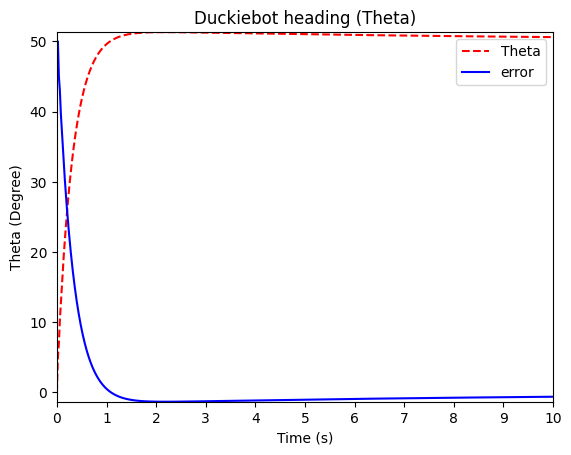

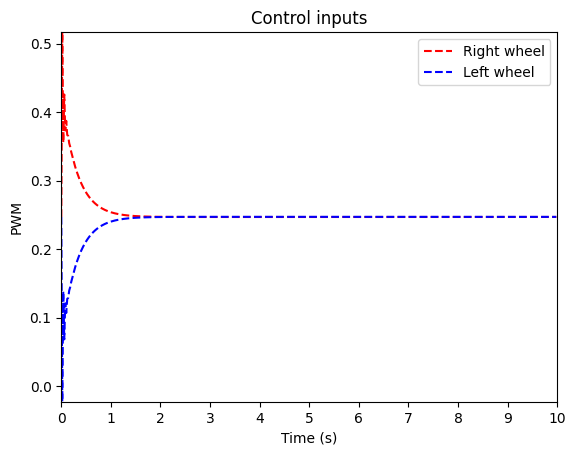

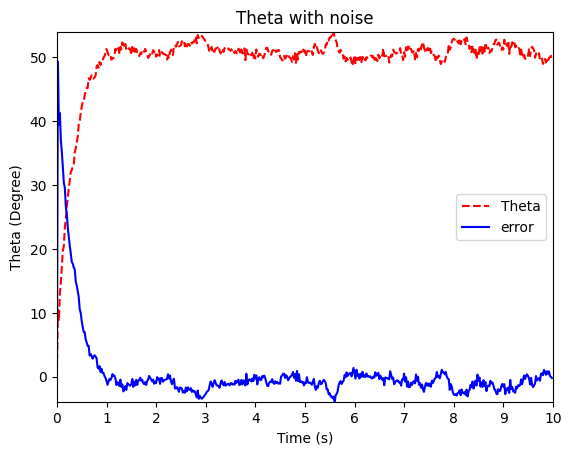

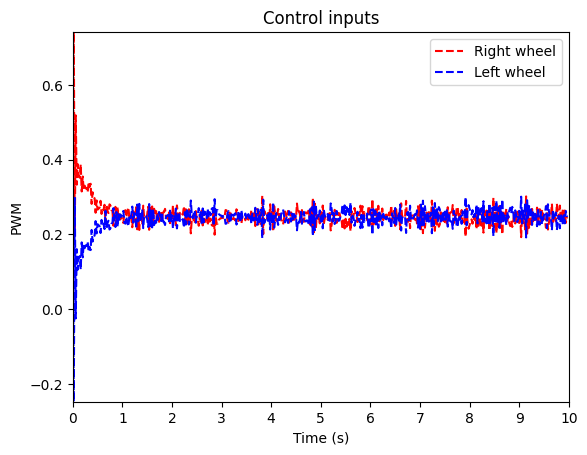

In [7]:
import sys, os
sys.path.insert(0, os.path.join(os.path.abspath(''), '../../packages'))

from tests.unit_test import UnitTestHeadingPID
from pid_controller import PIDController

import numpy as np

# This is for quick testing purposes only - you can try different values of v_init and R, L or the ones you determined before. Try to change R, L for fun.
v_test = 0.2
R_test = 0.018 # m
baseline_test = 0.1 # m
gain_test = 0.6 
trim_test = 0 
theta_ref= np.deg2rad(50) # in rad

# Sanity check (not a faithful representation of the actual behavior, given the motion model is assumed to be exactly known)
unit_test = UnitTestHeadingPID(R_test, baseline_test, v_test, theta_ref, gain_test, trim_test, PIDController)
unit_test.test()

## Step 2: Test the PID controller

Before running your PID controller on a real-world Duckiebot, start in the simulator to explore the limitations of your controller and tune the parameters for optimal behavior.

When moving from the simulator to your Duckiebot, keep in mind:

1. **Safety** — Run your Duckiebot in a space where it cannot fall off a table, go down stairs, or collide with anything fragile.

2. **Behavior changes** — Your Duckiebot will perform differently from the simulated one. The simulated hardware model cannot exactly match your assembled Duckiebot, and the physical environment introduces many types of error not present in simulation.

---

**Hint: Save your tuned controller coefficients that perform best in simulation before changing them for your Duckiebot. The following values are a good starting point:**

|    | Simulator | Duckiebot |
| -- | --------- | --------- |
| kp | 5         | 15        |
| ki | 0.2       | 1         |
| kd | 0.1       | 0.2       |

---

### 💻 Test the controller in simulation

1. Make sure you have implemented `PIDController` in `packages/pid_controller.py`.

2. Open a terminal, navigate to the **repository root** (`duckietown-rewritten/`), and run:

       python launch.py --sim --task modcon

   This will launch the Godot simulation and start the ModCon web interface.

3. Open your browser and navigate to `http://localhost:5000`.

4. Use the interface to set a heading reference and forward speed, then start a maneuver. You will see the robot attempt to reach and hold the target heading using your PID controller.

5. Tune the PID gains (`k_P`, `k_I`, `k_D`) live through the interface — changes are saved to `config/modcon_config.yaml`.

6. To stop the simulation, press `Ctrl-C` in the terminal.

To test different solutions, edit `packages/pid_controller.py` and relaunch. Remember that the odometry functions you wrote before play an important role here too, as the tracking errors are computed based on the odometry.

### 🚙 Test the controller on your Duckiebot

1. Make sure your Duckiebot is powered on and connected to the network (`http://ROBOTNAME.local:8000` should be accessible).

2. Open a terminal, navigate to the **repository root** (`duckietown-rewritten/`), and run:

       python launch.py --run --bot ROBOTNAME --task modcon

   Replace `ROBOTNAME` with your Duckiebot's hostname.

3. Open the URL printed by the command in your browser and follow the same steps as in the simulation.

**Note**: Start at very slow speeds with the physical Duckiebot and get a feel for the interface first. Going out of bounds in simulation is just a matter of relaunching.

<figure>
  <div style="text-align:center;">
  <img src="../../../assets/images/pid-control/pid-heading-control-real.png" alt="pid-heading-real-1" style="width: 300px;"/>
  <p>Duckiebot heading control with:
  
$$v_{0} = 1, \theta_{ref} = [0^\circ, 90^\circ, 180^\circ, 270^\circ, 0^\circ]$$
</p>
  </div>
</figure>

To test different solutions, edit `packages/pid_controller.py` and re-run the deploy command.

**Note**: Remember that the odometry functions you wrote before play an important role here too as the tracking errors are computed based on the odometry.

### 💡 Reflecting on the experience

After having played around with the PID controller, maybe testing different PID coefficients along with Duckiebot fixed speeds and distances to the reference trajectories, you might have noticed a few things:

- Need for tuning: There is a coupling between stability, performance, coefficients and magnitude of the tracking error. A set of coefficients that worked "well" for a given linear speed and distance from the reference, might not work as well with a different set of values. PID control _can_ produce good results, but it requires tuning to specific cases. 

- Input saturations: real robots have saturations (e.g. `omega_max` in the kinematics parameters, which has been set in previous activities). This means that occasionally having the controller act more aggressively will not change the system's response, as there are other real world constraints. Saturations might represent physical limitations of hardware (intuitively, the higher the value of the input, the higher "energy" it will take to actuate that command. Energy is not free, nor infinitely available.), or overarching safety constraints that have been put in place to prevent dangerous things from happening. When inputs saturate, errors (especially the integral one) might continue building up, causing a situation that will break the logic of the PID controller. For this reason, typically `anti wind-up` mechanisms are implemented to prevent either input saturation, of the integral error building up too much. There are many fancy `anti wind-up` strategies; we implemented a simple one in the controller above. 

- You never get perfect tracking, even with a very well tuned PID controller. Why? 

- The robot doesn't have the slightest idea of what is going on around it. This is beacause we are using interoceptive sensors (wheel encoders) to create the robot's belief. The **real** state of the robot is unknown to it. Moreover, lack of exteroceptive sensors (e.g., a camera) makes the robot unable to "anchor" its belief to some real-world feature, and perform sanity checks. You might have noticed that a Duckiebot will _not_ take that turn in your Duckietown autonomously, and that's because it has no notion of a map. For this very reason we will introduce cameras and computer vision in the future modules. 